# **Environment Setup and Data Mounting**

In [ ]:
TRAIN = False

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/ColabNotebooks/archive/"

In [ ]:
import os

print(os.listdir(BASE_PATH))

['HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'HAM10000_images_part_1', 'Ipd(preprocessing).ipynb', 'Final preprocessing.ipynb']


In [ ]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf

# **Path Configuration and Data Loading**

In [ ]:
BASE_PATH = "/content/drive/MyDrive/ColabNotebooks/archive/"

metadata_path = BASE_PATH + "HAM10000_metadata.csv"
images_path1 = BASE_PATH + "HAM10000_images_part_1/"
images_path2 = BASE_PATH + "HAM10000_images_part_2/"

# **Data Cleaning and Feature Engineering**

In [ ]:
df = pd.read_csv(metadata_path)

print("Metadata shape:", df.shape)
df.head()

Metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print(df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
image_paths = {}

for folder in [images_path1, images_path2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

In [ ]:
df['image_path'] = df['image_id'].map(image_paths)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/ColabNotebooks/archive/...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/ColabNotebooks/archive/...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/ColabNotebooks/archive/...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/ColabNotebooks/archive/...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/ColabNotebooks/archive/...


In [ ]:
print("Missing image paths:", df['image_path'].isnull().sum())

Missing image paths: 0


# **Dataset Splitting (Train, Validation, Test)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['dx'],
    random_state=42
)

In [ ]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['dx'],
    random_state=42
)

In [ ]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 8012
Validation size: 1001
Test size: 1002


In [ ]:
print("\nTrain distribution:")
print(train_df['dx'].value_counts())

print("\nValidation distribution:")
print(val_df['dx'].value_counts())

print("\nTest distribution:")
print(test_df['dx'].value_counts())


Train distribution:
dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64

Validation distribution:
dx
nv       670
mel      111
bkl      110
bcc       51
akiec     33
vasc      14
df        12
Name: count, dtype: int64

Test distribution:
dx
nv       671
mel      112
bkl      110
bcc       52
akiec     32
vasc      14
df        11
Name: count, dtype: int64


# **Handling Class Imbalance**

In [ ]:
import numpy as np

classes = np.unique(train_df['dx'])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{'akiec': np.float64(4.368593238822246), 'bcc': np.float64(2.7848453249913105), 'bkl': np.float64(1.3021290427433772), 'df': np.float64(12.440993788819876), 'mel': np.float64(1.2860353130016051), 'nv': np.float64(0.21338020666879728), 'vasc': np.float64(10.040100250626567)}


In [ ]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# **Image Preprocessing and Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_df['dx'] = train_df['dx'].astype(str)
val_df['dx'] = val_df['dx'].astype(str)
test_df['dx'] = test_df['dx'].astype(str)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 8012 validated image filenames belonging to 7 classes.


In [ ]:
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1001 validated image filenames belonging to 7 classes.


In [ ]:
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1002 validated image filenames belonging to 7 classes.


# **Generator Verification**

In [ ]:
print(train_generator.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [ ]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 7)


# **Import Libraries**

In [ ]:
import tensorflow as tf

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import ResNet50

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# **Create Callbacks (Training Improvements)**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# **Create Reusable Model Builder**

In [ ]:
def build_model(base_model):

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    predictions = Dense(7, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# **MobileNetV2**

In [ ]:
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_model = build_model(mobilenet_base)

mobilenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Train MobileNetV2**

In [ ]:
checkpoint_mobilenet = ModelCheckpoint(
    "mobilenet_best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [ ]:
if TRAIN:
    history_mobilenet = mobilenet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        class_weight=class_weights,
        callbacks=[early_stop, lr_scheduler, checkpoint_mobilenet]
    )

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6623 - loss: 1.0710

251/251 ━━━━━━━━━━━━━━━━━━━━ 2290s 9s/step - accuracy: 0.6911 - loss: 0.9163 - val_accuracy: 0.7233 - val_loss: 0.7961 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.7340 - loss: 0.7732

251/251 ━━━━━━━━━━━━━━━━━━━━ 192s 762ms/step - accuracy: 0.7310 - loss: 0.7721 - val_accuracy: 0.7383 - val_loss: 0.7477 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.7311 - loss: 0.7551

251/251 ━━━━━━━━━━━━━━━━━━━━ 181s 720ms/step - accuracy: 0.7414 - loss: 0.7382 - val_accuracy: 0.7443 - val_loss: 0.7275 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 712ms/step - accuracy: 0.7414 - loss: 0.7199 - val_accuracy: 0.7093 - val_loss: 0.7592 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.7434 - loss: 0.7110

251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 711ms/step - accuracy: 0.7502 - loss: 0.6950 - val_accuracy: 0.7502 - val_loss: 0.6959 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 183s 727ms/step - accuracy: 0.7566 - loss: 0.6680 - val_accuracy: 0.7443 - val_loss: 0.7117 - learning_rate: 0.0010
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 184s 733ms/step - accuracy: 0.7651 - loss: 0.6501 - val_accuracy: 0.7393 - val_loss: 0.7210 - learning_rate: 0.0010
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 701ms/step - accuracy: 0.7800 - loss: 0.6035 - val_accuracy: 0.7443 - val_loss: 0.6711 - learning_rate: 3.0000e-04
Epoch 9/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.7884 - loss: 0.5834

251/251 ━━━━━━━━━━━━━━━━━━━━ 177s 704ms/step - accuracy: 0.7846 - loss: 0.5917 - val_accuracy: 0.7532 - val_loss: 0.6704 - learning_rate: 3.0000e-04
Epoch 10/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.7898 - loss: 0.5874

251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 709ms/step - accuracy: 0.7889 - loss: 0.5814 - val_accuracy: 0.7632 - val_loss: 0.6758 - learning_rate: 3.0000e-04
Epoch 11/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.7948 - loss: 0.5711

251/251 ━━━━━━━━━━━━━━━━━━━━ 181s 723ms/step - accuracy: 0.7926 - loss: 0.5790 - val_accuracy: 0.7712 - val_loss: 0.6581 - learning_rate: 3.0000e-04
Epoch 12/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 715ms/step - accuracy: 0.7902 - loss: 0.5743 - val_accuracy: 0.7493 - val_loss: 0.6928 - learning_rate: 3.0000e-04
Epoch 13/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 713ms/step - accuracy: 0.7894 - loss: 0.5739 - val_accuracy: 0.7433 - val_loss: 0.6699 - learning_rate: 3.0000e-04
Epoch 14/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 715ms/step - accuracy: 0.8035 - loss: 0.5439 - val_accuracy: 0.7483 - val_loss: 0.6654 - learning_rate: 9.0000e-05


# **Fine-Tune MobileNetV2**

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
if TRAIN:
    history_mobilenet = mobilenet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        class_weight=class_weights,
        callbacks=[early_stop, lr_scheduler, checkpoint_mobilenet]
    )

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 715ms/step - accuracy: 0.7958 - loss: 0.5605 - val_accuracy: 0.7493 - val_loss: 0.6756 - learning_rate: 9.0000e-05
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 180s 717ms/step - accuracy: 0.7958 - loss: 0.5589 - val_accuracy: 0.7502 - val_loss: 0.6771 - learning_rate: 9.0000e-05
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 181s 720ms/step - accuracy: 0.8079 - loss: 0.5388 - val_accuracy: 0.7453 - val_loss: 0.6729 - learning_rate: 2.7000e-05


In [ ]:
for layer in mobilenet_model.layers[-30:]:
    layer.trainable = True

In [ ]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
if TRAIN:
    fine_tune_history_mobilenet = mobilenet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5,
        class_weight=class_weights,
        callbacks=[early_stop, lr_scheduler]
    )

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 214s 786ms/step - accuracy: 0.6953 - loss: 0.8959 - val_accuracy: 0.7453 - val_loss: 0.7149 - learning_rate: 1.0000e-05
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 714ms/step - accuracy: 0.7222 - loss: 0.7873 - val_accuracy: 0.7473 - val_loss: 0.7371 - learning_rate: 1.0000e-05
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 183s 726ms/step - accuracy: 0.7378 - loss: 0.7441 - val_accuracy: 0.7423 - val_loss: 0.7485 - learning_rate: 3.0000e-06


In [ ]:
if TRAIN:
    mobilenet_model.save("mobilenet_finetuned_skin_cancer_model.h5")

# **EfficientNetB0 and ResNet50**

In [ ]:
if TRAIN:
    efficientnet_base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    efficientnet_model = build_model(efficientnet_base)
    
    efficientnet_model.summary()
    checkpoint_efficientnet = ModelCheckpoint(
        "efficientnet_best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
    history_efficientnet = efficientnet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        class_weight=class_weights,
        callbacks=[early_stop, lr_scheduler, checkpoint_efficientnet]
    )
    for layer in efficientnet_model.layers[-30:]:
        layer.trainable = True
    efficientnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    fine_tune_history_efficientnet = efficientnet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5,
        class_weight=class_weights,
        callbacks=[early_stop, lr_scheduler]
    )
    efficientnet_model.save("efficientnet_finetuned_skin_cancer_model.h5")
    resnet_base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    resnet_model = build_model(resnet_base)
    
    resnet_model.summary()
    checkpoint_resnet = ModelCheckpoint(
        "resnet_best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
    history_resnet = resnet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        class_weight=class_weights,
        callbacks=[early_stop, lr_scheduler, checkpoint_resnet]
    )
    for layer in resnet_model.layers[-30:]:
        layer.trainable = True
    resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    fine_tune_history_resnet = resnet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5,
        class_weight=class_weights,
        callbacks=[early_stop, lr_scheduler]
    )
    resnet_model.save("resnet50_finetuned_skin_cancer_model.h5")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.6508 - loss: 1.2328 

251/251 ━━━━━━━━━━━━━━━━━━━━ 6989s 28s/step - accuracy: 0.6667 - loss: 1.1965 - val_accuracy: 0.6693 - val_loss: 1.1341 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 968s 4s/step - accuracy: 0.6695 - loss: 1.1712 - val_accuracy: 0.6693 - val_loss: 1.1375 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 979s 4s/step - accuracy: 0.6695 - loss: 1.1608 - val_accuracy: 0.6693 - val_loss: 1.1376 - learning_rate: 0.0010
Epoch 4/15
 11/251 ━━━━━━━━━━━━━━━━━━━━ 13:17 3s/step - accuracy: 0.6475 - loss: 1.2010

# **Evaluate Models**

In [ ]:
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_generator)

efficientnet_loss, efficientnet_acc = efficientnet_model.evaluate(test_generator)

resnet_loss, resnet_acc = resnet_model.evaluate(test_generator)

print("MobileNetV2 Accuracy:", mobilenet_acc)
print("EfficientNetB0 Accuracy:", efficientnet_acc)
print("ResNet50 Accuracy:", resnet_acc)


# **Confusion Matrix (Example MobileNet)**

In [ ]:
pred_mobilenet = mobilenet_model.predict(test_generator)

y_pred_mobilenet = np.argmax(pred_mobilenet, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred_mobilenet)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("MobileNetV2 Confusion Matrix")

plt.show()

# **Classification Report**

In [ ]:
print(classification_report(
    test_generator.classes,
    y_pred_mobilenet,
    target_names=list(test_generator.class_indices.keys())
))

# **Training Graphs**

In [ ]:
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# **Model Comparison**

In [ ]:
models = ["MobileNetV2","EfficientNetB0","ResNet50"]

accuracies = [mobilenet_acc, efficientnet_acc, resnet_acc]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# **Model Handling & Loading**

In [ ]:
from tensorflow.keras.models import load_model

try:
    loaded_model = load_model("mobilenet_best_model.h5", compile=False)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Failed to load model: {e}")

# **Prediction Function with Preprocessing**

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_for_prediction(image_path, target_size=(224, 224)):
    try:
        img = image.load_img(image_path, target_size=target_size)
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        return img_array
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

def predict_image(image_path, model, class_indices, top_k=3):
    img_array = preprocess_for_prediction(image_path)
    if img_array is None:
        return
        
    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = predictions.argsort()[-top_k:][::-1]
    
    idx_to_class = {v: k for k, v in class_indices.items()}
    
    print(f"Predictions for {image_path}:")
    for i in top_indices:
        print(f" - {idx_to_class[i]}: {predictions[i]:.4f}")
    
    return predictions

# sample_image_path = test_df['image_path'].iloc[0]
# predict_image(sample_image_path, loaded_model, test_generator.class_indices)

# **Robust Evaluation Pipeline & Visualization**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_pipeline(model, generator):
    print("Running evaluation pipeline...")
    
    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    
    class_labels = list(generator.class_indices.keys())
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", \
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.show()

if 'loaded_model' in locals():
    evaluate_pipeline(loaded_model, test_generator)

In [ ]:
# Run this before FGSM section
from tensorflow.keras.models import load_model

model = load_model("model/final_model.h5", compile=False)
model.trainable = False

## Adversarial Attack - FGSM

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def fgsm_attack(model, image, label, epsilon):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image, training=False)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)
    
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    
    # Generate the adversarial image
    adversarial_image = image + epsilon * signed_grad
    adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)
    return adversarial_image

def preprocess_single_image(path, target_size=(224, 224)):
    img = image.load_img(path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

Using image: c:\Users\Admin\Desktop\IPD\data\HAM10000_images_part_1\ISIC_0024306.jpg

--- Prediction Comparison ---
Original Prediction: Class 5 (Confidence: 0.9763)
Adversarial Prediction: Class 2 (Confidence: 0.7815)


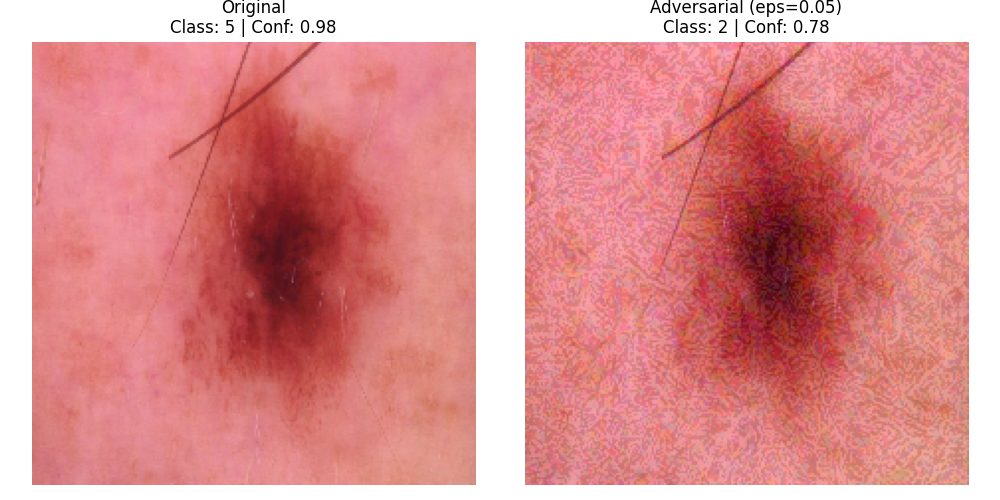

In [1]:
# Find an image from the dataset
import os
BASE_PATH = "/content/drive/MyDrive/ColabNotebooks/archive/"
images_path1 = BASE_PATH + "HAM10000_images_part_1/"
sample_image_path = None
if os.path.exists(images_path1):
    for f in os.listdir(images_path1):
        if f.endswith('.jpg'):
            sample_image_path = os.path.join(images_path1, f)
            break

if not sample_image_path and 'test_df' in locals():
    sample_image_path = test_df['image_path'].iloc[0]

if sample_image_path:
    print(f"Using image: {sample_image_path}")
    
    # Preprocess image
    img_tensor = preprocess_single_image(sample_image_path)
    
    # Get original prediction
    orig_pred = model.predict(img_tensor, verbose=0)[0]
    orig_class_idx = np.argmax(orig_pred)
    orig_conf = orig_pred[orig_class_idx]
    
    # Create a one-hot label for the original class for loss calculation in FGSM
    label_tensor = tf.one_hot(orig_class_idx, orig_pred.shape[0])
    label_tensor = tf.reshape(label_tensor, (1, orig_pred.shape[0]))
    
    # Apply FGSM
    epsilon = 0.05
    adv_image = fgsm_attack(model, img_tensor, label_tensor, epsilon)
    
    # Get adversarial prediction
    adv_pred = model.predict(adv_image, verbose=0)[0]
    adv_class_idx = np.argmax(adv_pred)
    adv_conf = adv_pred[adv_class_idx]
    
    # Print comparison
    print("\n--- Prediction Comparison ---")
    print(f"Original Prediction: Class {orig_class_idx} (Confidence: {orig_conf:.4f})")
    print(f"Adversarial Prediction: Class {adv_class_idx} (Confidence: {adv_conf:.4f})")
    
    # Visualization
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title(f"Original\nClass: {orig_class_idx} | Conf: {orig_conf:.2f}")
    plt.imshow(img_tensor[0])
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Adversarial (eps={epsilon})\nClass: {adv_class_idx} | Conf: {adv_conf:.2f}")
    plt.imshow(adv_image[0])
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Could not find a sample image.")

## Adversarial Attack - FGSM

In [ ]:
# Run this cell before FGSM
from tensorflow.keras.models import load_model

model = load_model("model/final_model.h5", compile=False)
model.trainable = False

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

def preprocess_single_image(path, target_size=(224, 224)):
    img = image.load_img(path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def fgsm_attack(model, img, label, epsilon):
    img = tf.convert_to_tensor(img, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img)
        prediction = model(img, training=False)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)

    gradient = tape.gradient(loss, img)
    signed_grad = tf.sign(gradient)

    adv_img = img + epsilon * signed_grad
    adv_img = tf.clip_by_value(adv_img, 0, 1)

    return adv_img

In [ ]:
import os

# 👉 CHANGE THIS PATH IF NEEDED
img_path = "data/HAM10000_images_part_1/ISIC_0027419.jpg"

if os.path.exists(img_path):
    img = preprocess_single_image(img_path)

    # Original prediction
    pred = model.predict(img, verbose=0)[0]
    orig_idx = np.argmax(pred)

    label = tf.one_hot(orig_idx, len(CLASS_NAMES))
    label = tf.reshape(label, (1, len(CLASS_NAMES)))

    # Apply FGSM
    epsilon = 0.02
    adv_img = fgsm_attack(model, img, label, epsilon)

    adv_pred = model.predict(adv_img, verbose=0)[0]
    adv_idx = np.argmax(adv_pred)

    print("\n--- Prediction Comparison ---")
    print(f"Original: {CLASS_NAMES[orig_idx]} ({pred[orig_idx]*100:.2f}%)")
    print(f"Adversarial: {CLASS_NAMES[adv_idx]} ({adv_pred[adv_idx]*100:.2f}%)")

    # Plot
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title(f"Original\n{CLASS_NAMES[orig_idx]}")
    plt.imshow(img[0])
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title(f"Adversarial\n{CLASS_NAMES[adv_idx]}")
    plt.imshow(adv_img[0])
    plt.axis("off")

    plt.show()

else:
    print("Image not found. Update img_path.")